# MNIST Handwritten Digit Classification Using a Neural Network

## 1. Import Required Libraries

The required Python libraries are imported for numerical computation, data visualization, image processing, and neural network development.

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

## 2. Load the MNIST Dataset

The MNIST dataset is loaded using Keras. It contains handwritten digit images labeled from 0 to 9.

In [70]:
(X_train, Y_train), (X_test, Y_test) =  mnist.load_data()

In [71]:
type(X_train)

numpy.ndarray

In [72]:
# shape of the numpy arrays
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


### Dataset Size

- Training data: 60,000 images
- Test data: 10,000 images

### 3. Understand the Dataset Shape

Each MNIST image has a dimension of **28 × 28 pixels** and is a grayscale image with a single channel.

The labels represent the digits **0 through 9**.

In [73]:
# printing the 10th image

print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [74]:
print(X_train[10].shape)

(28, 28)


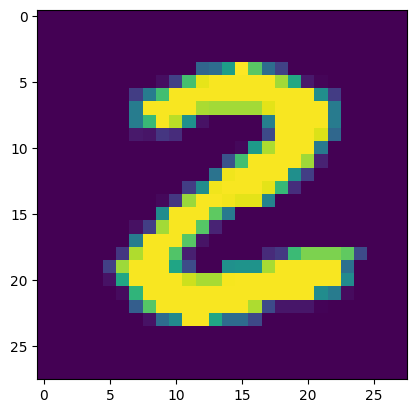

2


In [75]:
# displaying the image

plt.imshow(X_train[25])
plt.show()

# print the corresponding label
print(Y_train[25])

### 4. Understand the Image Labels

The MNIST labels represent the handwritten digits from **0 to 9**.

In [76]:
print(Y_train.shape, Y_test.shape)

(60000,) (10000,)


In [77]:
# unique values in Y_train
print(np.unique(Y_train))

# unique values in Y_test
print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


### Label Representation

The labels are integer class values from 0 to 9. Since the model uses sparse categorical crossentropy, one-hot encoding is not required.

### Image Dimensions

All MNIST images have the same dimensions of **28 × 28 pixels**, so resizing is not required for the training dataset.

In [78]:
# scaling the values

X_train = X_train/255
X_test = X_test/255

In [79]:
# printing the 10th image

print(X_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

## 5. Build the Neural Network

A feed-forward neural network is created to classify the handwritten digits.

The architecture consists of:
- A Flatten layer to convert each 28 × 28 image into a one-dimensional vector.
- Two Dense hidden layers using ReLU activation.
- An output Dense layer with 10 neurons using Softmax activation, representing the ten digit classes (0–9).

In [80]:
# Build the neural network architecture

model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,310 (165.27 KB)

 Trainable params: 42,310 (165.27 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
# Compile the neural network

model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [82]:
# Train the neural network for 10 epochs

model.fit(X_train, Y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9160 - loss: 0.2921
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9581 - loss: 0.1399
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9693 - loss: 0.1026
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9757 - loss: 0.0806
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9803 - loss: 0.0653
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9833 - loss: 0.0543
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9863 - loss: 0.0460
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9875 - loss: 0.0389
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9891 - loss: 0.0342
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9908 - loss: 0.0286


### Training Performance

The neural network achieved a training accuracy of **98.9%** after 10 epochs.

## 6. Evaluate the Model

The trained model is evaluated on the test dataset to measure its performance on previously unseen images.

In [83]:
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Loss: 0.1141
Test Accuracy: 97.09%


### Test Performance

The model achieved a test accuracy of **97.09%** with a test loss of **0.1182**.

In [84]:
print(X_test.shape)

(10000, 28, 28)


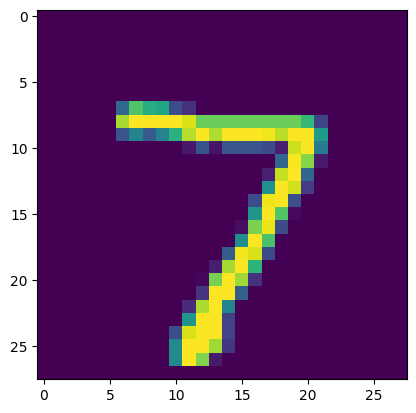

In [85]:
# first data point in X_test
plt.imshow(X_test[0])
plt.show()

In [86]:
print(Y_test[0])

7


In [87]:
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [88]:
print(Y_pred.shape)

(10000, 10)


In [89]:
print(Y_pred[0])

[1.4449154e-13 2.5066452e-08 2.6438298e-07 5.6361081e-04 2.6575035e-14
 2.3604116e-10 4.8682159e-19 9.9943578e-01 3.3454320e-08 2.1782276e-07]


## 7. Make Predictions

The `model.predict()` function generates prediction probabilities for each of the 10 digit classes for every test image.

In [90]:
# Convert prediction probabilities to a class label

label_for_first_test_image = np.argmax(Y_pred[0])
print(label_for_first_test_image)

7


In [91]:
# Convert prediction probabilities to class labels
Y_pred_labels = np.argmax(Y_pred, axis=1)

print("First 20 predicted labels:")
print(Y_pred_labels[:20])

First 20 predicted labels:
[7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]


### True Labels and Predicted Labels

- `Y_test`: Actual digit labels from the test dataset.
- `Y_pred_labels`: Digit labels predicted by the neural network.

## 8. Confusion Matrix

A confusion matrix is used to compare the actual digit labels with the predicted digit labels and identify classification errors across the ten digit classes.

In [92]:
conf_mat = confusion_matrix(Y_test, Y_pred_labels)

In [93]:
print(conf_mat)

tf.Tensor(
[[ 961    0    1    1    2    0    9    2    1    3]
 [   0 1124    2    0    1    0    4    1    3    0]
 [   7    6  988    6    3    1    3   14    4    0]
 [   0    0    2  986    1    9    0    6    4    2]
 [   0    0    3    0  963    0    8    4    0    4]
 [   2    0    0    8    5  864    9    0    4    0]
 [   1    3    2    2    3    2  944    1    0    0]
 [   1    6    6    4    2    0    0 1004    2    3]
 [   2    3    2   12    6    8    3    3  930    5]
 [   1    6    0    5   28    8    0   12    4  945]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted Labels')

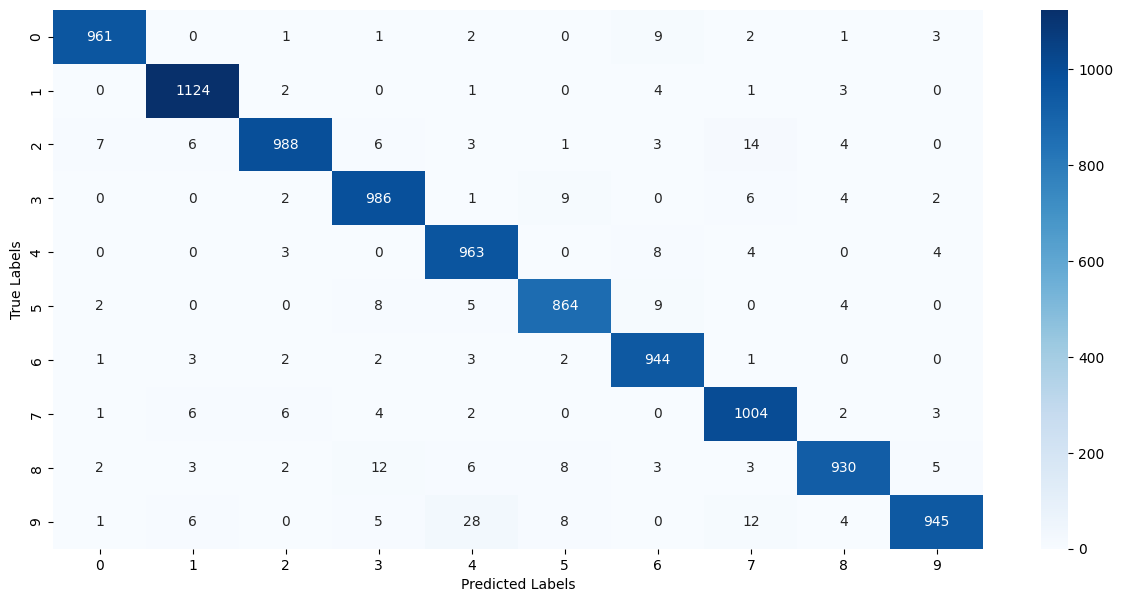

In [94]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

## 9. Build a Predictive System

The trained neural network is used to recognize a handwritten digit from an external image.

In [95]:
input_image_path = '/content/3-digit.PNG'

input_image = cv2.imread(input_image_path)

In [96]:
type(input_image)

numpy.ndarray

In [97]:
print(input_image)

[[[44 42 40]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[44 42 40]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[44 42 40]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 ...

 [[44 42 40]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[44 42 40]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[44 42 40]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]]


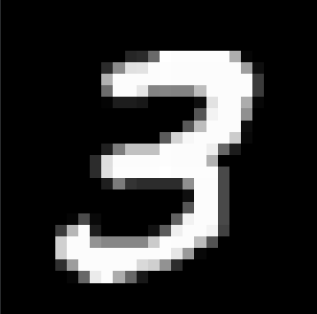

In [98]:
cv2_imshow(input_image)

In [99]:
input_image.shape

(314, 317, 3)

In [100]:
grayscale = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

In [101]:
grayscale.shape

(314, 317)

In [102]:
input_image_resize = cv2.resize(grayscale, (28, 28))

In [103]:
input_image_resize.shape

(28, 28)

In [104]:
cv2_imshow(input_image_resize)

In [105]:
input_image_resize = input_image_resize/255

In [106]:
type(input_image_resize)

numpy.ndarray

In [107]:
image_reshaped = np.reshape(input_image_resize, [1,28,28])

In [108]:
input_prediction = model.predict(image_reshaped, verbose=0)

In [109]:
input_pred_label = np.argmax(input_prediction)

In [110]:
print(input_pred_label)

3


## 10. Single-Image Prediction

A separate handwritten digit image is loaded and preprocessed before being passed to the trained neural network.

The image is:
1. Converted to grayscale.
2. Resized to 28 × 28 pixels.
3. Normalized to the range 0–1.
4. Reshaped to match the model input.
5. Classified using the trained neural network.

The predicted digit is obtained using `argmax()`.

Path of the image to be predicted: /content/3-digit.PNG


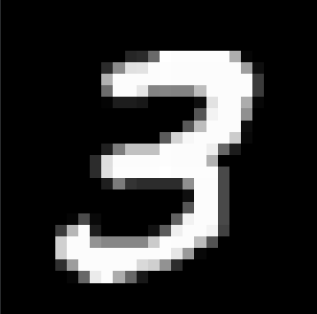

The Handwritten Digit is recognised as 3


In [111]:
# Load and predict a single handwritten digit image

input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

if input_image is None:
    raise FileNotFoundError(f"Image not found: {input_image_path}")

cv2_imshow(input_image)

grayscale = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

input_image_resize = cv2.resize(grayscale, (28, 28))

input_image_resize = input_image_resize / 255.0

image_reshaped = np.reshape(input_image_resize, [1, 28, 28])

input_prediction = model.predict(image_reshaped, verbose=0)

input_pred_label = np.argmax(input_prediction)

print('The Handwritten Digit is recognised as', input_pred_label)

# Conclusion

This project demonstrates the use of a neural network for handwritten digit classification using the MNIST dataset.

The model was trained for 10 epochs using the Adam optimizer and sparse categorical crossentropy loss. The final model achieved:

- **Training Accuracy:** 98.9%
- **Test Accuracy:** 97.09%
- **Test Loss:** 0.1182

The trained model successfully generated predictions for the MNIST test dataset and correctly recognized the supplied handwritten digit image as **3**.

Overall, the project demonstrates the basic workflow of image classification using a neural network, including data loading, preprocessing, model building, training, evaluation, prediction, and single-image classification.